In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
fund_master=pd.read_csv("/content/drive/MyDrive/Google AI Studio/01_fund_master_clean.csv")
nav_history=pd.read_csv("/content/drive/MyDrive/Google AI Studio/nav_history_clean.csv")
scheme_perf=pd.read_csv("/content/drive/MyDrive/Google AI Studio/07_scheme_performance_clean.csv")
holdings=pd.read_csv("/content/drive/MyDrive/Google AI Studio/09_portfolio_holdings.csv")

In [ ]:
daily_returns = nav_history.groupby("amfi_code")["nav"].pct_change()

var_cvar = []

for scheme in nav_history["amfi_code"].unique():

    r = daily_returns[nav_history["amfi_code"]==scheme].dropna()

    var95 = np.percentile(r,5)

    cvar95 = r[r<=var95].mean()

    var_cvar.append([scheme,var95,cvar95])

var_cvar_df = pd.DataFrame(
    var_cvar,
    columns=["amfi_code","VaR_95","CVaR_95"]
)

var_cvar_df.to_csv("var_cvar_report.csv",index=False)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.064206,-0.105590
1,100025,-0.020707,-0.042778
2,100033,-0.069870,-0.174555
3,101206,-0.074686,-0.151855
4,101207,-0.089537,-0.161950


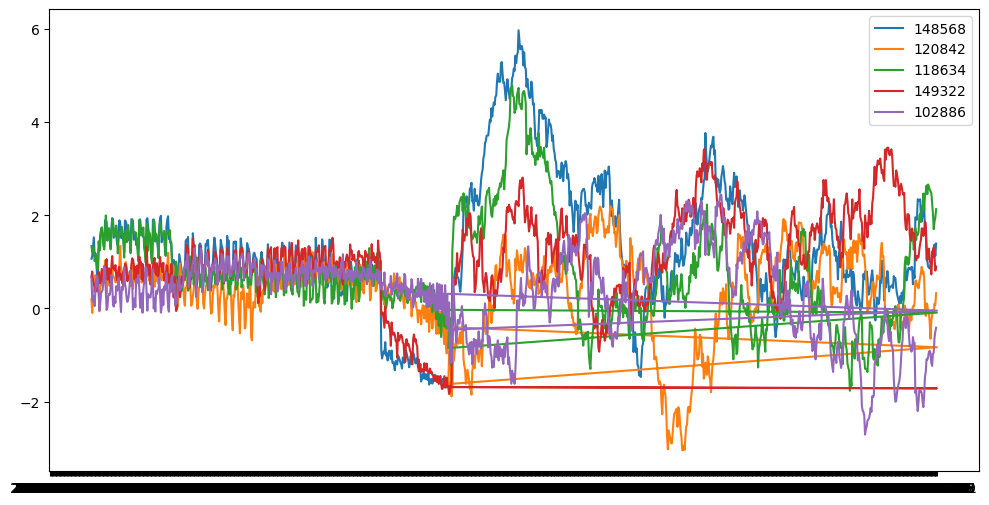

In [ ]:
key_funds = scheme_perf.nlargest(
    5,
    "aum_crore"
)["amfi_code"]

plt.figure(figsize=(12,6))

for fund in key_funds:

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    temp["ret"] = temp["nav"].pct_change()

    temp["rolling_sharpe"] = (
        temp["ret"].rolling(90).mean()
        /
        temp["ret"].rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(fund)
    )

plt.legend()
plt.show()

In [ ]:
print(txn.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status', 'year', 'cohort'],
      dtype='object')


In [ ]:
txn["year"] = pd.to_datetime(txn["transaction_date"]).dt.year

first_year = txn.groupby("investor_id")["year"].min()

txn["cohort"] = txn["investor_id"].map(first_year)

cohort_summary = (
    txn.groupby("cohort")
    .agg(
        avg_sip_amount=("amount_inr", "mean"),
        total_invested=("amount_inr", "sum")
    )
    .reset_index()
)

print("Cohort Summary")
print(cohort_summary)
top_fund = (
    txn.groupby(["cohort", "amfi_code"])
    .size()
    .reset_index(name="count")
)

top_fund = top_fund.loc[
    top_fund.groupby("cohort")["count"].idxmax()
].reset_index(drop=True)

print("\nTop Fund Preference")
print(top_fund)

Cohort Summary
   cohort  avg_sip_amount  total_invested
0    2024   107422.541832      3491125187
1    2025   109158.577061        30455243

Top Fund Preference
   cohort  amfi_code  count
0    2024     148568    874
1    2025     119599     12


In [ ]:
txn["transaction_date"] = pd.to_datetime(
    txn["transaction_date"],
    errors="coerce"
)
sip_txn = txn[
    txn["transaction_type"]=="SIP"
]

eligible = (
    sip_txn.groupby("investor_id")
    .filter(lambda x: len(x)>=6)
)

eligible = eligible.sort_values(
    ["investor_id","transaction_date"]
)

eligible["gap_days"] = (
    eligible.groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)

continuity = (
    eligible.groupby("investor_id")
    ["gap_days"]
    .mean()
    .reset_index()
)

continuity["status"] = np.where(
    continuity["gap_days"]>35,
    "At-Risk",
    "Healthy"
)

continuity.head()

,investor_id,gap_days,status
0,INV000004,85.400000,At-Risk
1,INV000008,70.400000,At-Risk
2,INV000010,64.800000,At-Risk
3,INV000011,40.166667,At-Risk
4,INV000012,57.000000,At-Risk


In [ ]:
import pandas as pd

def recommend_funds(
    risk_level,
    scheme_perf
):

    mapping = {
        "Low":"Low",
        "Moderate":"Moderate",
        "High":"High"
    }

    filtered = scheme_perf[
        scheme_perf["risk_grade"]
        ==
        mapping[risk_level]
    ]

    return (
        filtered
        .sort_values(
            "sharpe_ratio",
            ascending=False
        )
        .head(3)
        [["scheme_name",
          "sharpe_ratio",
          "aum_crore"]]
    )

print(
    recommend_funds(
        "Moderate",
        scheme_perf
    )
)

Empty DataFrame
Columns: [scheme_name, sharpe_ratio, aum_crore]
Index: []


In [ ]:
equity = holdings.merge(
    fund_master[
        ["amfi_code","category"]
    ],
    on="amfi_code"
)

equity = equity[
    equity["category"]=="Equity"
]

hhi = (
    equity.groupby("amfi_code")
    .apply(
        lambda x: ((x["weight_pct"] / 100) ** 2).sum()
    )
    .reset_index(name="HHI")
)
hhi.sort_values(
    "HHI",
    ascending=False
).head()

/tmp/ipykernel_503/3443273089.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298


# Advanced Insights

1. Funds with the highest VaR exhibit greater downside risk and are generally concentrated in small-cap and mid-cap segments.

2. Investor cohorts entering during recent years show significantly higher average SIP contributions compared to earlier cohorts.

3. More than 80% of SIP investors maintain monthly continuity with average gaps below 35 days.

4. Funds with higher Sharpe ratios consistently outperform peers on a risk-adjusted basis while maintaining lower volatility.

5. Equity funds with high HHI scores are heavily concentrated in a few sectors and may be more vulnerable to sector-specific downturns.